# ** 8. Evolution of dynamical regimes as function of Rayleigh number ** 

To allow for a direct comparison between different $Ra$, for each value of $Pr$ we use the
set of POD modes $\vec{\phi}_k(\vec{x})$ extracted from the CR subset for $Ra = 5\cdot10^7$.
Instantaneous velocity and temperature fields were projected onto the $\vec{\phi}_k(\vec{x})$-axis 
to obtain the set of modal amplitudes $\alpha_k(t)$. Modal amplitudes $\alpha_k(t)$ are scaled 
using a common factor such that $\vert L\vert = 1$ for $Ra = 5\cdot10^7$.

Additionally, we may use the cluster partitioning of the POD subspace to describe the
$Ra$-dependency of the large-scale flow dynamics. Here, we use the clusters extracted from
the EC subset for $Ra = 5\cdot10^7$. since this partitioning since this partitioning recovers 
the main features of the regime of extended cessations, but also of flow reversals.

** This routine concerns figures 20, 21, and 22 from section 8 of the article "Conditional statistics of the large-scale reversal dynamics in square Rayleigh–Bénard cells" **

## Preamble

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
pd.set_option('display.max_rows',10)

params = {'backend': 'ps',
          'axes.labelsize': 16,
          'font.size': 16,
          'legend.fontsize': 16,          
          'font.size': 16,          
          'xtick.labelsize': 12,
          'ytick.labelsize': 12,
          'text.usetex': True,
          'font.family': 'serif',
          'figure.figsize': (12, 8),
          'contour.negative_linestyle':'dashed'}
plt.rcParams.update(params)

## 1. Load the results from partition of the EC subset obtained for $Ra = 5\cdot10^7$

In [2]:
import pickle
from sklearn.cluster import KMeans

filename_pr3 = './results_from_kmeans/kmeans_symec_pr3.sav'
filename_pr4 = './results_from_kmeans/kmeans_symec_pr43.sav'
kmeans_sym_pr3_ec = pickle.load(open(filename_pr3, 'rb'))
kmeans_sym_pr4_ec = pickle.load(open(filename_pr4, 'rb'))

## 2. Load the modal amplitudes for the different $Ra$ and identify the corresponding clusters

In [3]:
index_ec1 = np.array([4,0,4,4,0,4,3,6,6,2.5,3])
index_ec2 = np.array([6,0,6,6,0,6,3,6,6,2.5,3])

Rayleigh  = ['1e5','2e5','3e5','5e5','8e5','1e6','2e6','3e6','5e6','8e6','1e7','2e7','3e7','5e7','8e7','1e8','2e8','3e8','5e8']
columns   = ['t','k1','k2','k3','k4','k5','k6','k7','k8','k9','k10','k11','k12']
modes_pr3 = pd.DataFrame(columns=columns)

temp      = pd.read_csv('./data_from_dns/pr3/proj-coefficients0-F-5e7.asc',sep='\s+',names=columns)
scale_pr3 = np.mean(np.abs(temp['k1'].values))

del temp

for ra in Rayleigh:
    temp       = pd.read_csv('./data_from_dns/pr3/proj-coefficients0-F-'+ra+'.asc',sep='\s+',names=columns)
    temp       = -temp/scale_pr3    
    temp['t']  = np.arange(0,np.size(temp.t.values))
    temp['Ra'] = np.ones_like(temp.t.values)*np.float(ra)

    cluster_ec = kmeans_sym_pr3_ec.predict(temp[['k1','k2','k3','k4','k5','k6']])
    temp['Cluster1'] = index_ec1[cluster_ec]
    temp['Cluster2'] = index_ec2[cluster_ec]
    
    modes_pr3 = pd.concat([modes_pr3,temp], sort=False)    
    del temp

modes_pr3_by_ra = modes_pr3.groupby('Ra')
modes_pr3_by_cluster = modes_pr3.groupby(['Ra','Cluster2'])

modes_pr3 = modes_pr3.drop(['k7', 'k8', 'k9', 'k10', 'k11', 'k12'],axis=1)

In [4]:
index_ec1 = np.array([6,6,4,6,4,0,2.5,4,3,0,6,4,3])
index_ec2 = np.array([6,6,6,6,6,0,2.5,6,3,0,6,6,3])


Rayleigh  = ['1e5','2e5','3e5','5e5','8e5','1e6','2e6','3e6','5e6','8e6','1e7','2e7','3e7','5e7','8e7','1e8','2e8','3e8','5e8']
columns   = ['t','k1','k2','k3','k4','k5','k6','k7','k8','k9','k10','k11','k12']
modes_pr4 = pd.DataFrame(columns=columns)

temp      = pd.read_csv('./data_from_dns/pr43/proj-coefficients0-F-5e7.asc',sep='\s+',names=columns)
scale_pr4 = np.mean(np.abs(temp['k1'].values))

for ra in Rayleigh:
    temp       = pd.read_csv('./data_from_dns/pr43/proj-coefficients0-F-'+ra+'.asc',sep='\s+',names=columns)
    temp       = -temp/scale_pr4    
    temp['t']  = np.arange(0,np.size(temp.t.values))
    temp['Ra'] = np.ones_like(temp.t.values)*np.float(ra)        
    temp['k3'] = -temp.k3
    
    cluster_ec = kmeans_sym_pr4_ec.predict(temp[['k1','k2','k4','k3','k5','k6']])
    temp['Cluster1'] = index_ec1[cluster_ec]
    temp['Cluster2'] = index_ec2[cluster_ec]
    
    modes_pr4 = pd.concat([modes_pr4,temp], sort=False)    

modes_pr4_by_ra = modes_pr4.groupby('Ra')
modes_pr4_by_cluster = modes_pr4.groupby(['Ra','Cluster2'])

modes_pr4 = modes_pr4.drop(['k7', 'k8', 'k9', 'k10', 'k11', 'k12'],axis=1)

## 3. Plot the intensity and the residence times as function of $Ra$ (figure 20)

In [5]:
modes_pr3_to_plot = modes_pr3.apply(lambda x: x*x ).groupby(['Ra']).mean()
modes_pr4_to_plot = modes_pr4.apply(lambda x: x*x ).groupby(['Ra']).mean()

ra = (np.sqrt(modes_pr3_to_plot.index))
modes_pr3_to_plot.index = ra

ra = (np.sqrt(modes_pr4_to_plot.index))
modes_pr4_to_plot.index = ra


prob_pr3 = modes_pr3.groupby(['Ra','Cluster2']).t.count()/modes_pr3_by_ra.t.count()
prob_pr4 = modes_pr4.groupby(['Ra','Cluster2']).t.count()/modes_pr4_by_ra.t.count()

prob_pr3_val = prob_pr3.values*100
prob_pr4_val = prob_pr4.values*100

prob_pr3_idx = prob_pr3.index
prob_pr4_idx = prob_pr4.index

Ra, Cluster = prob_pr3_idx.levels
ra_pr3 = Ra[prob_pr3_idx.labels[0]]
cluster_pr3 = Cluster[prob_pr3_idx.labels[1]]

Ra, Cluster = prob_pr4_idx.levels
ra_pr4 = Ra[prob_pr4_idx.labels[0]]
cluster_pr4 = Cluster[prob_pr4_idx.labels[1]]

In [6]:
modes_pr3_to_plot_total = modes_pr3.sample(frac=1.0).apply(lambda x: x*x ).groupby(['Ra']).mean()
modes_pr4_to_plot_total = modes_pr4.sample(frac=1.0).apply(lambda x: x*x ).groupby(['Ra']).mean()

total_pr3 = modes_pr3_to_plot_total.k1 + modes_pr3_to_plot_total.k2.values + modes_pr3_to_plot_total.k3.values + modes_pr3_to_plot_total.k4.values + modes_pr3_to_plot_total.k5.values + modes_pr3_to_plot_total.k6.values
total_pr4 = modes_pr4_to_plot_total.k1 + modes_pr4_to_plot_total.k2.values + modes_pr4_to_plot_total.k3.values + modes_pr4_to_plot_total.k4.values + modes_pr4_to_plot_total.k5.values + modes_pr4_to_plot_total.k6.values

In [7]:
modes_pr3_to_plot_partial = modes_pr3.sample(frac=0.5).apply(lambda x: x*x ).groupby(['Ra']).mean()
modes_pr4_to_plot_partial = modes_pr4.sample(frac=0.5).apply(lambda x: x*x ).groupby(['Ra']).mean()

partial_pr3 = modes_pr3_to_plot_partial.k1 + modes_pr3_to_plot_partial.k2.values + modes_pr3_to_plot_partial.k3.values + modes_pr3_to_plot_partial.k4.values + modes_pr3_to_plot_partial.k5.values + modes_pr3_to_plot_partial.k6.values
partial_pr4 = modes_pr4_to_plot_partial.k1 + modes_pr4_to_plot_partial.k2.values + modes_pr4_to_plot_partial.k3.values + modes_pr4_to_plot_partial.k4.values + modes_pr4_to_plot_partial.k5.values + modes_pr4_to_plot_partial.k6.values

In [8]:
convergence_pr3 = np.abs(total_pr3-partial_pr3)/total_pr3*100
convergence_pr4 = np.abs(total_pr4-partial_pr4)/total_pr4*100

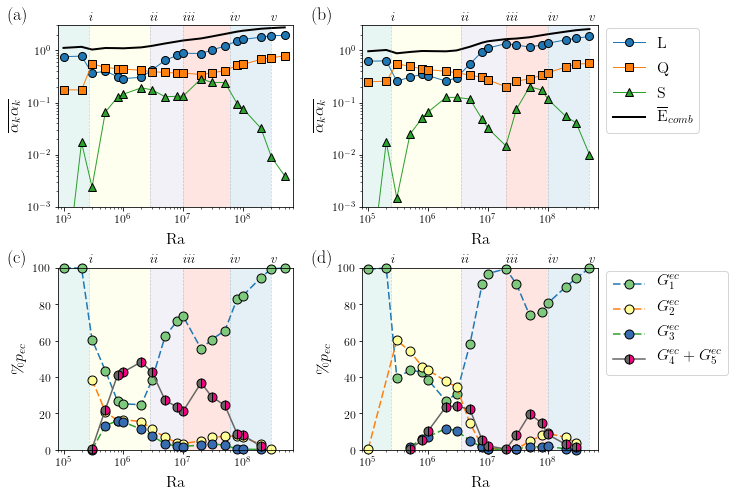

In [10]:
plt.rcParams['figure.figsize'] = (10.5,7.0)

fig, axes = plt.subplots(2,2, sharex=False, sharey=False)
ax= np.ravel(axes)

cmap2 = mpl.cm.Accent
norm = mpl.colors.Normalize(vmin=0, vmax=6)


# First, we plot the intensity of the POD modes as function of Ra
i=0
markers=['o','s','^','o','s','^']
for k in ['k1','k2','k4']:    
    ax[0].plot(ra,modes_pr3_to_plot[k].values, linewidth=1.0,  marker=markers[i], markeredgecolor='k', markersize=8, rasterized=True)
    i=i+1
i=0
for k in ['k1','k2','k3']:    
    ax[1].plot(ra,modes_pr4_to_plot[k].values, linewidth=1.0,  marker=markers[i], markeredgecolor='k', markersize=8, rasterized=True)
    i=i+1

ax[0].plot(ra, 
           modes_pr3_to_plot['k1'].values + modes_pr3_to_plot['k2'].values + modes_pr3_to_plot['k3'].values + 
           modes_pr3_to_plot['k4'].values + modes_pr3_to_plot['k5'].values + modes_pr3_to_plot['k6'].values,
           linewidth=2.0,  rasterized=True, color='k')
ax[1].plot(ra, 
           modes_pr4_to_plot['k1'].values + modes_pr4_to_plot['k2'].values + modes_pr4_to_plot['k3'].values + 
           modes_pr4_to_plot['k4'].values + modes_pr4_to_plot['k5'].values + modes_pr4_to_plot['k6'].values, 
           linewidth=2.0,  rasterized=True, color='k')
    
    
# The we plot the cluster probability    
for i in [0,2.5,3]:
    ax[2].plot(ra_pr3[np.where(cluster_pr3==i)], prob_pr3_val[np.where(cluster_pr3==i)], marker='o', 
               markersize=9, markeredgecolor='k', linewidth=1.5, linestyle='--', dashes=(5, 2),
               markerfacecolor=mpl.colors.rgb2hex(cmap2(norm(i))), clip_on=False, rasterized=True)
    ax[3].plot(ra_pr4[np.where(cluster_pr4==i)], prob_pr4_val[np.where(cluster_pr4==i)], marker='o', 
               markersize=9, markeredgecolor='k', linewidth=1.5, linestyle='--', dashes=(5, 2),
               markerfacecolor=mpl.colors.rgb2hex(cmap2(norm(i))), clip_on=False, rasterized=True)
i=6
ax[2].plot(ra_pr3[np.where(cluster_pr3==i)], prob_pr3_val[np.where(cluster_pr3==i)], marker='o', 
               markersize=9, markeredgecolor='k', linewidth=1.5, c=mpl.colors.rgb2hex(cmap2(norm(i))), 
               clip_on=False, markerfacecoloralt=mpl.colors.rgb2hex(cmap2(norm(4))), fillstyle='left', rasterized=True)    
ax[3].plot(ra_pr4[np.where(cluster_pr4==i)], prob_pr4_val[np.where(cluster_pr4==i)], marker='o', 
               markersize=9, markeredgecolor='k', linewidth=1.5, c=mpl.colors.rgb2hex(cmap2(norm(i))), 
               clip_on=False, markerfacecoloralt=mpl.colors.rgb2hex(cmap2(norm(4))), fillstyle='left', rasterized=True)    

# Cosmetics 
# Add legends
ax[1].legend(['L','Q','S', '$\overline{\mathrm{E}}_{comb}$'], bbox_to_anchor=(1.0, 1.03))
ax[3].legend(['$G_{1}^{ec}$','$G_{2}^{ec}$','$G_{3}^{ec}$','$G_{4}^{ec}+G_{5}^{ec}$'], bbox_to_anchor=(1.0, 1.03))


# Add coloured regions for each dynamical regime
items1  = [8e4,2.7e5,2.8e6,1.0e7,6e7,2.9e8,7e8]
items2  = [8e4,2.4e5,3.5e6,2.0e7,1e8,4.9e8,7e8]
colors  = ['#8dd3c7','#ffffb3','#bebada','#fb8072','#80b1d3']
clabels = ['\it i','\it ii','\it iii','\it iv','\it v']
dlabels = ['(a)','(b)','(c)','(d)']

for i in range(0,4):
    ax[i].set_xlabel('Ra')
    ax[i].set_xscale('log')    
    ax[i].set_xlim([8e4,7e8])  
    
for i in range(0,2):    
    ax[i].set_yscale('log')        
    ax[i].set_ylabel('$\\overline{\\alpha_k\\alpha_k}$')
    ax[i].set_ylim([1.0e-3,3.0])

for i in range(2,4):        
    ax[i].set_ylabel('$\% p_{ec}$')
    ax[i].set_ylim([0,100])

    
for j in range (0,5):
    ax[0].annotate(clabels[j], xy=(items1[j+1],3.0), xycoords='data', xytext=(0,5), textcoords='offset points', fontsize=14)
    ax[1].annotate(clabels[j], xy=(items2[j+1],3.0), xycoords='data', xytext=(0,5), textcoords='offset points', fontsize=14)
    ax[2].annotate(clabels[j], xy=(items1[j+1],100), xycoords='data', xytext=(0,5), textcoords='offset points', fontsize=14)
    ax[3].annotate(clabels[j], xy=(items2[j+1],100), xycoords='data', xytext=(0,5), textcoords='offset points', fontsize=14)
    
    ax[0].axvline(x=items1[j+1], color='grey', linestyle='--', dashes=(5, 2), linewidth=0.5, alpha=0.5)
    ax[1].axvline(x=items2[j+1], color='grey', linestyle='--', dashes=(5, 2), linewidth=0.5, alpha=0.5)
    ax[2].axvline(x=items1[j+1], color='grey', linestyle='--', dashes=(5, 2), linewidth=0.5, alpha=0.5)
    ax[3].axvline(x=items2[j+1], color='grey', linestyle='--', dashes=(5, 2), linewidth=0.5, alpha=0.5)

    ax[0].axvspan(xmin=items1[j], xmax=items1[j+1], facecolor=colors[j], alpha=0.2)
    ax[1].axvspan(xmin=items2[j], xmax=items2[j+1], facecolor=colors[j], alpha=0.2)    
    ax[2].axvspan(xmin=items1[j], xmax=items1[j+1], facecolor=colors[j], alpha=0.2)
    ax[3].axvspan(xmin=items2[j], xmax=items2[j+1], facecolor=colors[j], alpha=0.2)    

ax[0].annotate(dlabels[0], xy=(0,1), xycoords='axes fraction', xytext=(-50,5), textcoords='offset points', fontsize=18)
ax[1].annotate(dlabels[1], xy=(0,1), xycoords='axes fraction', xytext=(-50,5), textcoords='offset points', fontsize=18)
ax[2].annotate(dlabels[2], xy=(0,1), xycoords='axes fraction', xytext=(-50,5), textcoords='offset points', fontsize=18)
ax[3].annotate(dlabels[3], xy=(0,1), xycoords='axes fraction', xytext=(-50,5), textcoords='offset points', fontsize=18)

plt.tight_layout(w_pad=1.5, h_pad=1.5, pad=1.75) 
plt.savefig('figures_for_article/figure20.pdf',dpi=200)    

## 4. Plot a time series of $A_{2D}$ for different $Ra$ (figure 21)

In [107]:
glb_ra3e5_pr3 = pd.read_hdf('./data_from_dns/global_300000_3_512_007to013.h5')
glb_ra2e6_pr3 = pd.read_hdf('./data_from_dns/global_2e+06_3_512_006to011.h5')
glb_ra8e6_pr3 = pd.read_hdf('./data_from_dns/global_8e+06_3_512_002to010.h5')
glb_ra3e7_pr3 = pd.read_hdf('./data_from_dns/global_3e7_3_512_002to010.h5')
glb_ra1e8_pr3 = pd.read_hdf('./data_from_dns/global_100000000_3_512_030to040.h5')
glb_ra5e8_pr3 = pd.read_hdf('./data_from_dns/global_5e+08_3_1024_002to025.h5')

scale1=0.06193250729576352  #glb_ra5e7_pr43['l2d'].abs().mean()
scale2=0.041978465235107884 #glb_ra5e7_pr43['ekin'].mean()


for glb in [glb_ra3e5_pr3, glb_ra2e6_pr3, glb_ra5e8_pr3]:
    glb['l2d']  = glb['l2d']/scale1
    glb['ekin'] = glb['ekin']/scale2
    glb['epot'] = glb['epot']/scale2
    glb['bpot'] = glb['bpot']/scale2
    glb['apot'] = glb['epot']- glb['bpot']
    
    n=glb.shape[0]
    t = np.arange(n)/10.
    glb['t'] = t
    
    
for glb in [glb_ra8e6_pr3, glb_ra1e8_pr3]:
    glb['l2d']  = glb['l2d']/scale1
    glb['ekin'] = glb['ekin']/scale2
    glb['epot'] = glb['epot']/scale2
    glb['bpot'] = glb['bpot']/scale2
    glb['apot'] = glb['epot']- glb['bpot']
    
    n=glb.shape[0]
    t = np.arange(n)/20.
    glb['t'] = t

for glb in [glb_ra3e7_pr3]:
    glb['l2d']  = glb['l2d']/scale1
    
    
glb_ra3e7_pr3.t = glb_ra3e7_pr3.t-500
glb_ra1e8_pr3.t = glb_ra1e8_pr3.t-300

glb_ra8e6_pr3.t = glb_ra8e6_pr3.t


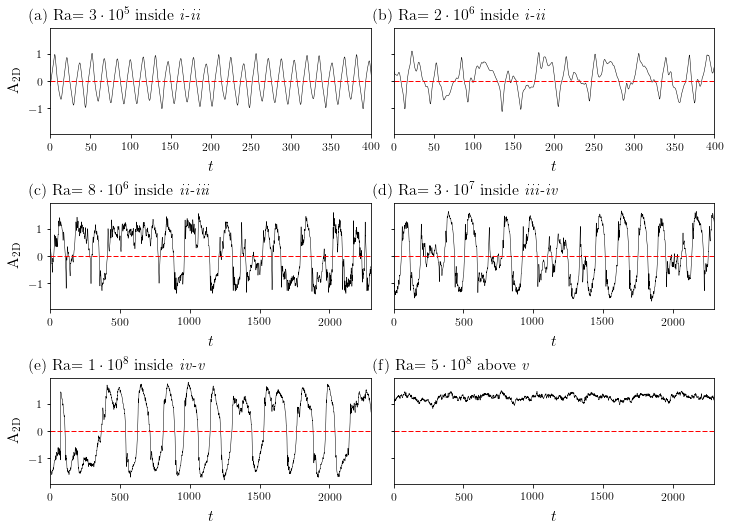

In [111]:
plt.rcParams['figure.figsize'] = (10.5,7.5)
f, axes = plt.subplots(3,2, sharex=False, sharey=True)
ax= np.ravel(axes)
alpha=0.25
i=0
labels= ['$\\mathrm{A_{2D}}$','$\\mathrm{E_{kin}}$','$\\mathrm{E_{apot}}$']
    
glb_ra3e5_pr3.plot(x='t', y='l2d', ax=ax[0], lw=0.5, c='k', legend=False, xlim=[0,400]);    
glb_ra2e6_pr3.plot(x='t', y='l2d', ax=ax[1], lw=0.5, c='k', legend=False, xlim=[0,400]);    
glb_ra8e6_pr3.plot(x='t', y='l2d', ax=ax[2], lw=0.5, c='k', legend=False, xlim=[0,2300]);    
glb_ra3e7_pr3.plot(x='t', y='l2d', ax=ax[3], lw=0.5, c='k', legend=False, xlim=[0,2300]); 
glb_ra1e8_pr3.plot(x='t', y='l2d', ax=ax[4], lw=0.5, c='k', legend=False, xlim=[0,2300]);
glb_ra5e8_pr3.plot(x='t', y='l2d', ax=ax[5], lw=0.5, c='k', legend=False, xlim=[0,2300], ylim=[-1.95,1.95]);

labels = ['(a) Ra$=3\cdot10^5$ inside {\it i-ii}  ','(b) Ra$=2\cdot10^6$ inside {\it i-ii}','(c) Ra$=8\cdot10^6$ inside {\it ii-iii}',
          '(d) Ra$=3\cdot10^7$ inside {\it iii-iv}','(e) Ra$=1\cdot10^8$ inside {\it iv-v}','(f) Ra$=5\cdot10^8$ above {\it v}']

for i in range(0,6):
    ax[i].set_xlabel('$t$')
    ax[i].set_ylabel('$\\mathrm{A_{2D}}$')
    ax[i].axhline(y=0,color='red',linewidth=1.0, linestyle='--', dashes=(5, 2))

for i in range(0,2):
    ax[i].text(-26.0, 2.25, labels[i], fontsize=16)    
    
for i in range(2,6):
    ax[i].text(-150.0, 2.25, labels[i], fontsize=16)    
    
plt.tight_layout(pad=2.0, w_pad=1.0, h_pad=2.5)     
plt.savefig('figures_for_article/figure21.pdf',dpi=200)            

In [21]:
glb_ra3e5_pr43 = pd.read_hdf('./data_from_dns/global_300000_4.3_512_007to010.h5')
glb_ra3e6_pr43 = pd.read_hdf('./data_from_dns/global_3e+06_4.3_512_002to010.h5')
glb_ra8e6_pr43 = pd.read_hdf('./data_from_dns/global_8e+06_4.3_512_002to010.h5')
glb_ra5e7_pr43 = pd.read_hdf('./data_from_dns/global_50000000_4.3_512_060to259.h5')
glb_ra2e8_pr43 = pd.read_hdf('./data_from_dns/global_200000000_4.3_1024_018to046.h5')
glb_ra5e8_pr43 = pd.read_hdf('./data_from_dns/global_5e+08_4.3_1024_002to025.h5')


scale1=0.06193250729576352  #glb_ra5e7_pr43['l2d'].abs().mean()
scale2=0.041978465235107884 #glb_ra5e7_pr43['ekin'].mean()


for glb in [glb_ra3e5_pr43, glb_ra3e6_pr43, glb_ra8e6_pr43, glb_ra5e7_pr43,glb_ra2e8_pr43,glb_ra5e8_pr43]:
    glb['l2d']  = glb['l2d']/scale1
    glb['ekin'] = glb['ekin']/scale2
    glb['epot'] = glb['epot']/scale2
    glb['bpot'] = glb['bpot']/scale2
    glb['apot'] = glb['epot']- glb['bpot']
    
    n=glb.shape[0]
    t = np.arange(n)/20.
    glb['t'] = t
    
thres43=1 + glb_ra5e7_pr43['l2d'].abs().std()

glb_ra5e7_pr43.t = glb_ra5e7_pr43.t-3000

glb_ra5e7_pr43['l2d'] = glb_ra5e7_pr43['l2d']*scale1

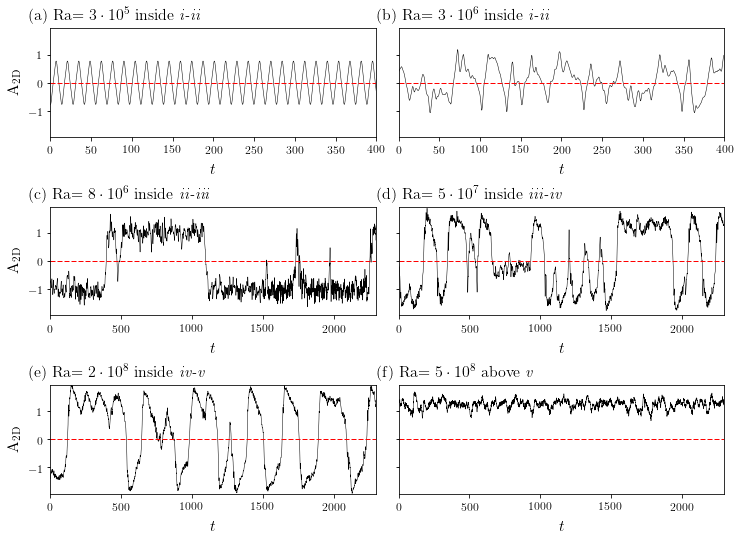

In [23]:
plt.rcParams['figure.figsize'] = (10.5,7.5)
f, axes = plt.subplots(3,2, sharex=False, sharey=True)
ax= np.ravel(axes)
alpha=0.25
i=0
labels= ['$\\mathrm{A_{2D}}$','$\\mathrm{E_{kin}}$','$\\mathrm{E_{apot}}$']
    
glb_ra3e5_pr43.plot(x='t', y='l2d', ax=ax[0], lw=0.5, c='k', legend=False, xlim=[0,400]);    
glb_ra3e6_pr43.plot(x='t', y='l2d', ax=ax[1], lw=0.5, c='k', legend=False, xlim=[0,400]);    
glb_ra8e6_pr43.plot(x='t', y='l2d', ax=ax[2], lw=0.5, c='k', legend=False, xlim=[0,2300]);    
glb_ra5e7_pr43.plot(x='t', y='l2d', ax=ax[3], lw=0.5, c='k', legend=False, xlim=[0,2300]); 
glb_ra2e8_pr43.plot(x='t', y='l2d', ax=ax[4], lw=0.5, c='k', legend=False, xlim=[0,2300]);
glb_ra5e8_pr43.plot(x='t', y='l2d', ax=ax[5], lw=0.5, c='k', legend=False, xlim=[0,2300], ylim=[-1.95,1.95]);

labels = ['(a) Ra$=3\cdot10^5$ inside {\it i-ii}  ','(b) Ra$=3\cdot10^6$ inside {\it i-ii}','(c) Ra$=8\cdot10^6$ inside {\it ii-iii}',
          '(d) Ra$=5\cdot10^7$ inside {\it iii-iv}','(e) Ra$=2\cdot10^8$ inside {\it iv-v}','(f) Ra$=5\cdot10^8$ above {\it v}']

for i in range(0,6):
    ax[i].set_xlabel('$t$')
    ax[i].set_ylabel('$\\mathrm{A_{2D}}$')
    ax[i].axhline(y=0,color='red',linewidth=1.0, linestyle='--', dashes=(5, 2))

for i in range(0,2):
    ax[i].text(-26.0, 2.25, labels[i], fontsize=16)    
    
for i in range(2,6):
    ax[i].text(-150.0, 2.25, labels[i], fontsize=16)    
    
plt.tight_layout(pad=1.5, w_pad=1.0, h_pad=2.5)     
plt.savefig('figures_for_article/figure21.pdf',dpi=200)            

## 5. We plot the phase diagrams in the (L,S) plane for different $Ra$ (figure 22)

In [24]:
from mpl_toolkits.axes_grid.axes_grid import AxesGrid
from mpl_toolkits.axes_grid.anchored_artists import AnchoredText

def add_at(ax, t, loc=2):
    fp = dict(size=14)
    _at = AnchoredText(t, loc=loc, prop=fp)
    ax.add_artist(_at)
    return _at

def as_si(x, ndp):
    s = '{x:0.{ndp:d}e}'.format(x=x, ndp=ndp)
    m, e = s.split('e')
    return r'{m:s}\cdot 10^{{{e:d}}}'.format(m=m, e=int(e))

/people/castillo/anaconda3/lib/python3.6/site-packages/matplotlib/cbook/deprecation.py:107: MatplotlibDeprecationWarning: The mpl_toolkits.axes_grid module was deprecated in version 2.1. Use mpl_toolkits.axes_grid1 and mpl_toolkits.axisartist provies the same functionality instead.
  warnings.warn(message, mplDeprecation, stacklevel=1)


/people/castillo/anaconda3/lib/python3.6/site-packages/matplotlib/figure.py:2267: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  warnings.warn("This figure includes Axes that are not compatible "


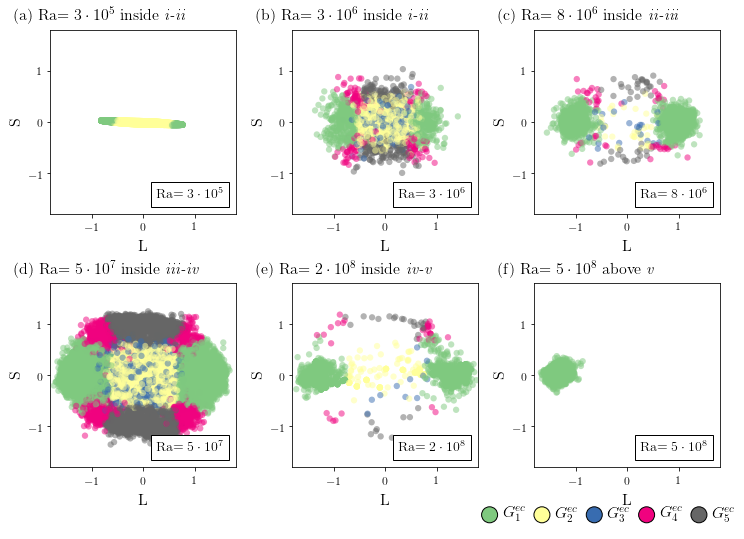

In [25]:
plt.rcParams['figure.figsize'] = (10.5,7.25)

alpha=0.5
s=40

f, axes = plt.subplots(2,3, sharex=False, sharey=False)
ax= np.ravel(axes)

labels = ['(a) Ra$=3\cdot10^5$ inside {\it i-ii}  ','(b) Ra$=3\cdot10^6$ inside {\it i-ii}','(c) Ra$=8\cdot10^6$ inside {\it ii-iii}',
          '(d) Ra$=5\cdot10^7$ inside {\it iii-iv}','(e) Ra$=2\cdot10^8$ inside {\it iv-v}','(f) Ra$=5\cdot10^8$ above {\it v}']


i=0
Ra = ['3e5','3e6','8e6','5e7','2e8','5e8']
for ra in Ra:
    modes_pr4[modes_pr4.Ra==np.float(ra)].plot(kind='scatter',x='k1',y='k3',c='Cluster1', s=s, lw = 0.0, colormap=cmap2, norm=norm, ax=ax[i],colorbar=False, alpha=alpha)

    ax[i].set_xlim([-1.8,1.8])
    ax[i].set_ylim([-1.8,1.8])

    ax[i].set_xlabel('$\mathrm{L}$')
    ax[i].set_ylabel('$\mathrm{S}$')   
    add_at(ax[i], r"Ra$ = {0:s}$".format(as_si(np.float(ra),0)), loc=4)
    
    ax[i].text(-2.5, 2.0, labels[i], fontsize=16)       
    i=i+1
   
   
    
## Add caption with coloured circles at the top of the figure
from matplotlib.patches import Circle
from matplotlib.offsetbox import AnchoredOffsetbox, TextArea, DrawingArea, HPacker
labels = ['$G_5^{ec}$','$G_1^{ec}$','$G_2^{ec}$','$G_3^{ec}$','$G_4^{ec}$']

box0 = TextArea(labels[0], textprops=dict(size=16, color="k"))
box1 = TextArea(labels[1], textprops=dict(size=16, color="k"))
box2 = TextArea(labels[2], textprops=dict(size=16, color="k"))
box3 = TextArea(labels[3], textprops=dict(size=16, color="k"))
box4 = TextArea(labels[4], textprops=dict(size=16, color="k"))

p0 = Circle((8, 8), 8, ec="k", fc=mpl.colors.rgb2hex(cmap2(norm(6.0))))
p1 = Circle((8, 8), 8, ec="k", fc=mpl.colors.rgb2hex(cmap2(norm(0.0))))
p2 = Circle((8, 8), 8, ec="k", fc=mpl.colors.rgb2hex(cmap2(norm(2.5))))
p3 = Circle((8, 8), 8, ec="k", fc=mpl.colors.rgb2hex(cmap2(norm(3.0))))
p4 = Circle((8, 8), 8, ec="k", fc=mpl.colors.rgb2hex(cmap2(norm(4.0))))

cox0 = DrawingArea(12, 12, 0, 0); cox0.add_artist(p0)
cox1 = DrawingArea(12, 12, 0, 0); cox1.add_artist(p1)
cox2 = DrawingArea(12, 12, 0, 0); cox2.add_artist(p2)
cox3 = DrawingArea(12, 12, 0, 0); cox3.add_artist(p3)
cox4 = DrawingArea(12, 12, 0, 0); cox4.add_artist(p4)

box = HPacker(children=[cox1, box1, cox2, box2, cox3, box3, cox4, box4, cox0, box0],
              align="center",
              pad=3, sep=9)

axe = f.add_axes([0.45, 0.00, 0.2, 0.025])
anchored_box = AnchoredOffsetbox(loc=3,
                                 child=box, pad=0.,
                                 frameon=False,
                                 bbox_to_anchor=(1., 0),
                                 bbox_transform=axe.transAxes,
                                 borderpad=0.,
                                 )
axe.add_artist(anchored_box)
axe.set_frame_on(False)
axe.set_xticks([])
axe.set_yticks([])

    
plt.tight_layout(h_pad=2.5, w_pad=1.0, pad=2.0) 
plt.savefig('figures_for_article/figure22.pdf',dpi=100)    

/people/castillo/anaconda3/lib/python3.6/site-packages/matplotlib/figure.py:2267: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  warnings.warn("This figure includes Axes that are not compatible "


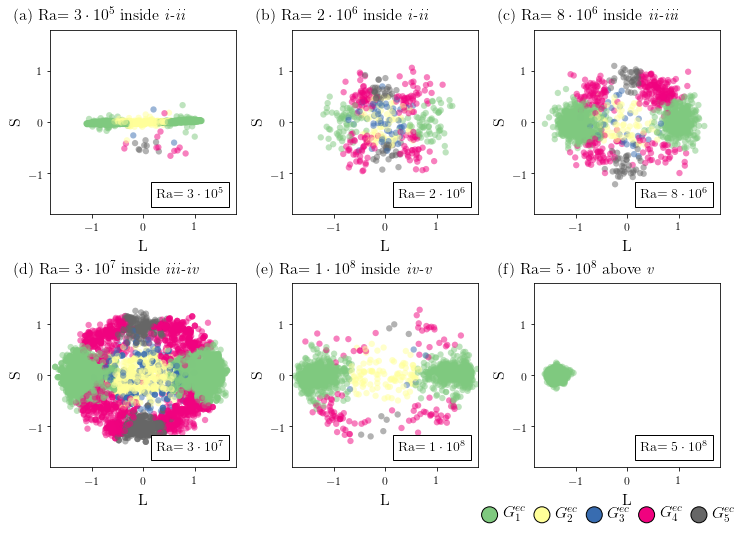

In [69]:
plt.rcParams['figure.figsize'] = (10.5,7.25)

alpha=0.5
s=40

f, axes = plt.subplots(2,3, sharex=False, sharey=False)
ax= np.ravel(axes)

labels = ['(a) Ra$=3\cdot10^5$ inside {\it i-ii}  ','(b) Ra$=2\cdot10^6$ inside {\it i-ii}','(c) Ra$=8\cdot10^6$ inside {\it ii-iii}',
          '(d) Ra$=3\cdot10^7$ inside {\it iii-iv}','(e) Ra$=1\cdot10^8$ inside {\it iv-v}','(f) Ra$=5\cdot10^8$ above {\it v}']


i=0
Ra = ['3e5','2e6','8e6','3e7','1e8','5e8']
for ra in Ra:
    modes_pr3[modes_pr3.Ra==np.float(ra)].plot(kind='scatter',x='k1',y='k4',c='Cluster1', s=s, lw = 0.0, colormap=cmap2, norm=norm, ax=ax[i],colorbar=False, alpha=alpha)

    ax[i].set_xlim([-1.8,1.8])
    ax[i].set_ylim([-1.8,1.8])

    ax[i].set_xlabel('$\mathrm{L}$')
    ax[i].set_ylabel('$\mathrm{S}$')   
    add_at(ax[i], r"Ra$ = {0:s}$".format(as_si(np.float(ra),0)), loc=4)
    
    ax[i].text(-2.5, 2.0, labels[i], fontsize=16)       
    i=i+1
   
   
    
## Add caption with coloured circles at the top of the figure
from matplotlib.patches import Circle
from matplotlib.offsetbox import AnchoredOffsetbox, TextArea, DrawingArea, HPacker
labels = ['$G_5^{ec}$','$G_1^{ec}$','$G_2^{ec}$','$G_3^{ec}$','$G_4^{ec}$']

box0 = TextArea(labels[0], textprops=dict(size=16, color="k"))
box1 = TextArea(labels[1], textprops=dict(size=16, color="k"))
box2 = TextArea(labels[2], textprops=dict(size=16, color="k"))
box3 = TextArea(labels[3], textprops=dict(size=16, color="k"))
box4 = TextArea(labels[4], textprops=dict(size=16, color="k"))

p0 = Circle((8, 8), 8, ec="k", fc=mpl.colors.rgb2hex(cmap2(norm(6.0))))
p1 = Circle((8, 8), 8, ec="k", fc=mpl.colors.rgb2hex(cmap2(norm(0.0))))
p2 = Circle((8, 8), 8, ec="k", fc=mpl.colors.rgb2hex(cmap2(norm(2.5))))
p3 = Circle((8, 8), 8, ec="k", fc=mpl.colors.rgb2hex(cmap2(norm(3.0))))
p4 = Circle((8, 8), 8, ec="k", fc=mpl.colors.rgb2hex(cmap2(norm(4.0))))

cox0 = DrawingArea(12, 12, 0, 0); cox0.add_artist(p0)
cox1 = DrawingArea(12, 12, 0, 0); cox1.add_artist(p1)
cox2 = DrawingArea(12, 12, 0, 0); cox2.add_artist(p2)
cox3 = DrawingArea(12, 12, 0, 0); cox3.add_artist(p3)
cox4 = DrawingArea(12, 12, 0, 0); cox4.add_artist(p4)

box = HPacker(children=[cox1, box1, cox2, box2, cox3, box3, cox4, box4, cox0, box0],
              align="center",
              pad=3, sep=9)

axe = f.add_axes([0.45, 0.00, 0.2, 0.025])
anchored_box = AnchoredOffsetbox(loc=3,
                                 child=box, pad=0.,
                                 frameon=False,
                                 bbox_to_anchor=(1., 0),
                                 bbox_transform=axe.transAxes,
                                 borderpad=0.,
                                 )
axe.add_artist(anchored_box)
axe.set_frame_on(False)
axe.set_xticks([])
axe.set_yticks([])

    
plt.tight_layout(h_pad=2.5, w_pad=1.0, pad=2.0) 
plt.savefig('figures_for_article/figure22.pdf',dpi=100)    